# 4 — The spectral route: the central charge from the leading eigenvalue

The second route to $c$ needs no eigenvectors at all. The leading eigenvalue $\mu_0(T)$ of
the transfer matrix carries a phase, and CFT fixes how that phase moves along the $T$ ladder
(Eq. (3) of the thesis):

$$\frac{\varphi(T)}{T} = a_0 - \frac{\pi}{T} + \frac{C}{T^2},
\qquad c = \frac{24\,v\,|C|}{\pi},$$

with $v(p)$ from equilibrium (notebook 1). The extensive term $a_0$ is non-universal; the
$-\pi/T$ term is the branch offset of $\lambda_0 = \log(-\mu_0)$ and is pinned — fitted
free it returns $B/\pi = -1.0000$, so it carries no physics; the $1/T^2$ curvature is the
measurement.

In [1]:
# load the library: model Hamiltonians, the temporal-MPO construction, the block power
# method, the entropy routines, and the plotting theme
include("../src/thesislib.jl")
using JLD2, Printf, Statistics
thesis_plot_theme!()

## The trajectory and the fits

Left: $\mu_0$ on the unit circle, normalised by the mean modulus of its own ladder — the
modulus is flat while the phase winds, which is why the phase is the useful part. Right: the
Eq. (3) fit per coupling with the extensive term removed, so the curvature that carries $c$
is visible by eye.

p=0.0  29 rungs T=2..20  c = 0.4510
p=0.1  15 rungs T=2..9  c = 0.4660


p=0.3  11 rungs T=2..7  c = 0.4936
p=0.5   9 rungs T=2..6  c = 0.5332


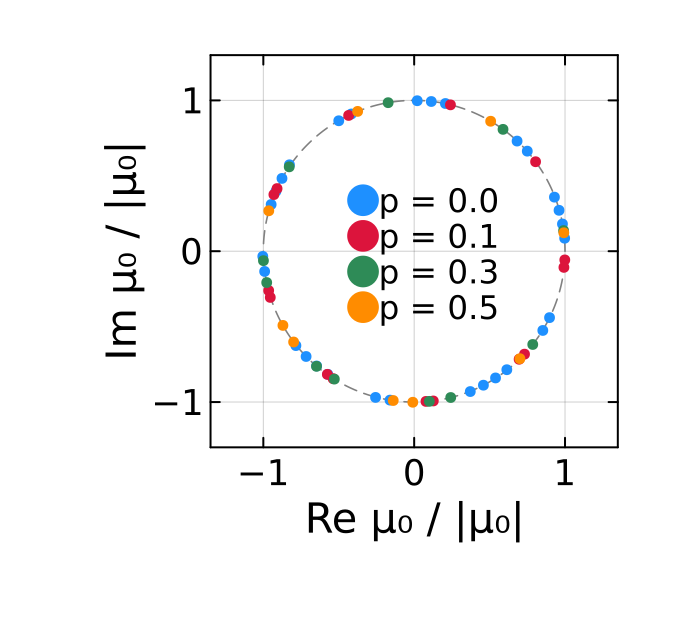

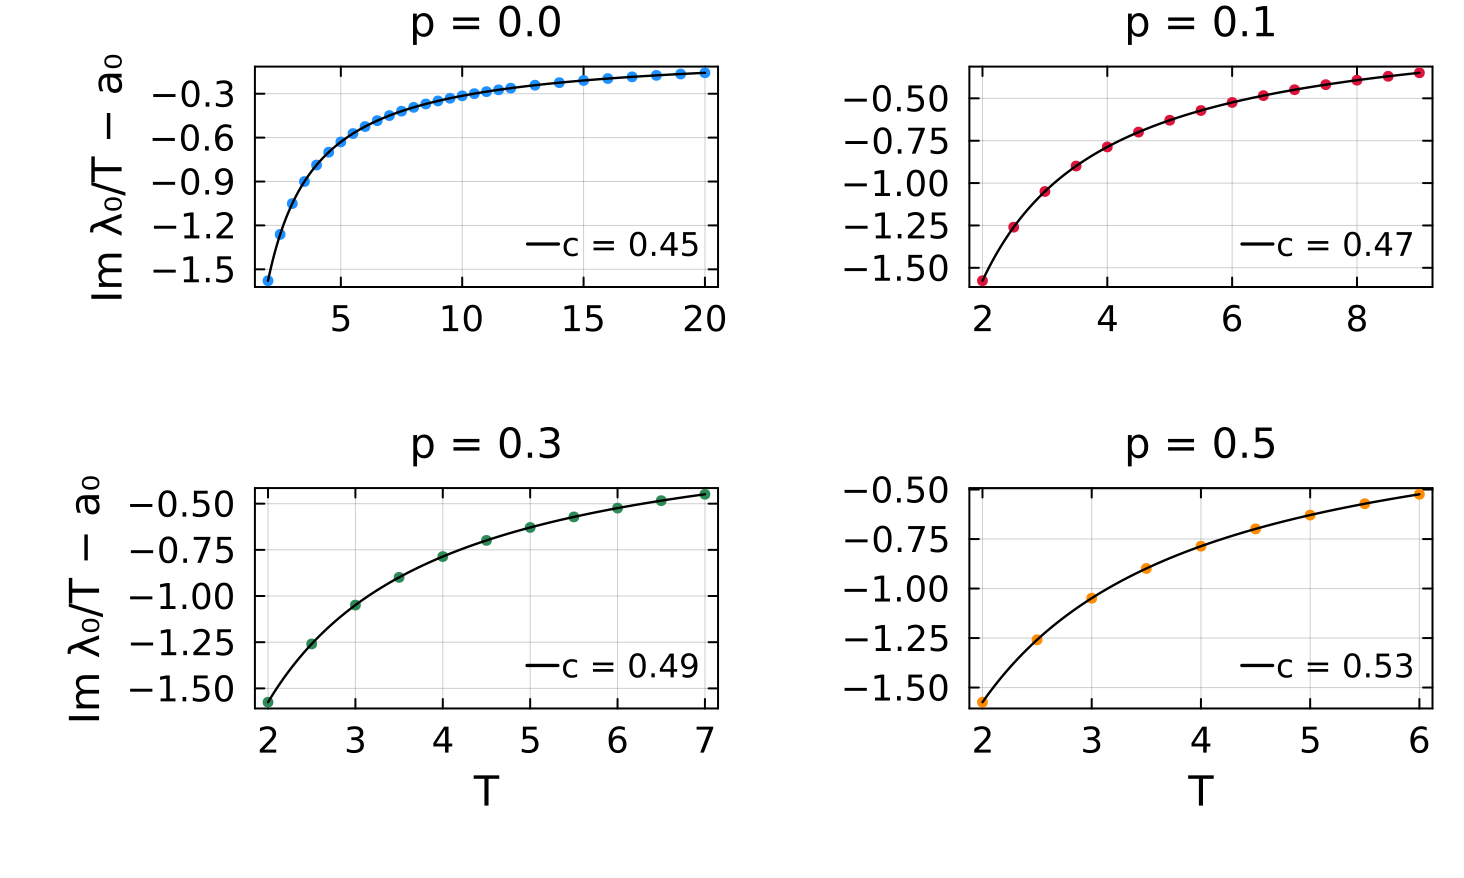

In [2]:
include("../scripts/figures/fig_spectral.jl")
sp = make_spectral()
display(sp.circle)
sp.eq3

## The same data, without the normalisation

Dividing by the mean modulus makes the four couplings comparable, but it hides something
pretty: each coupling lives on its **own** circle, whose radius is the extensive free-energy
density in disguise. Same caches, no normalisation, one dashed circle per coupling:

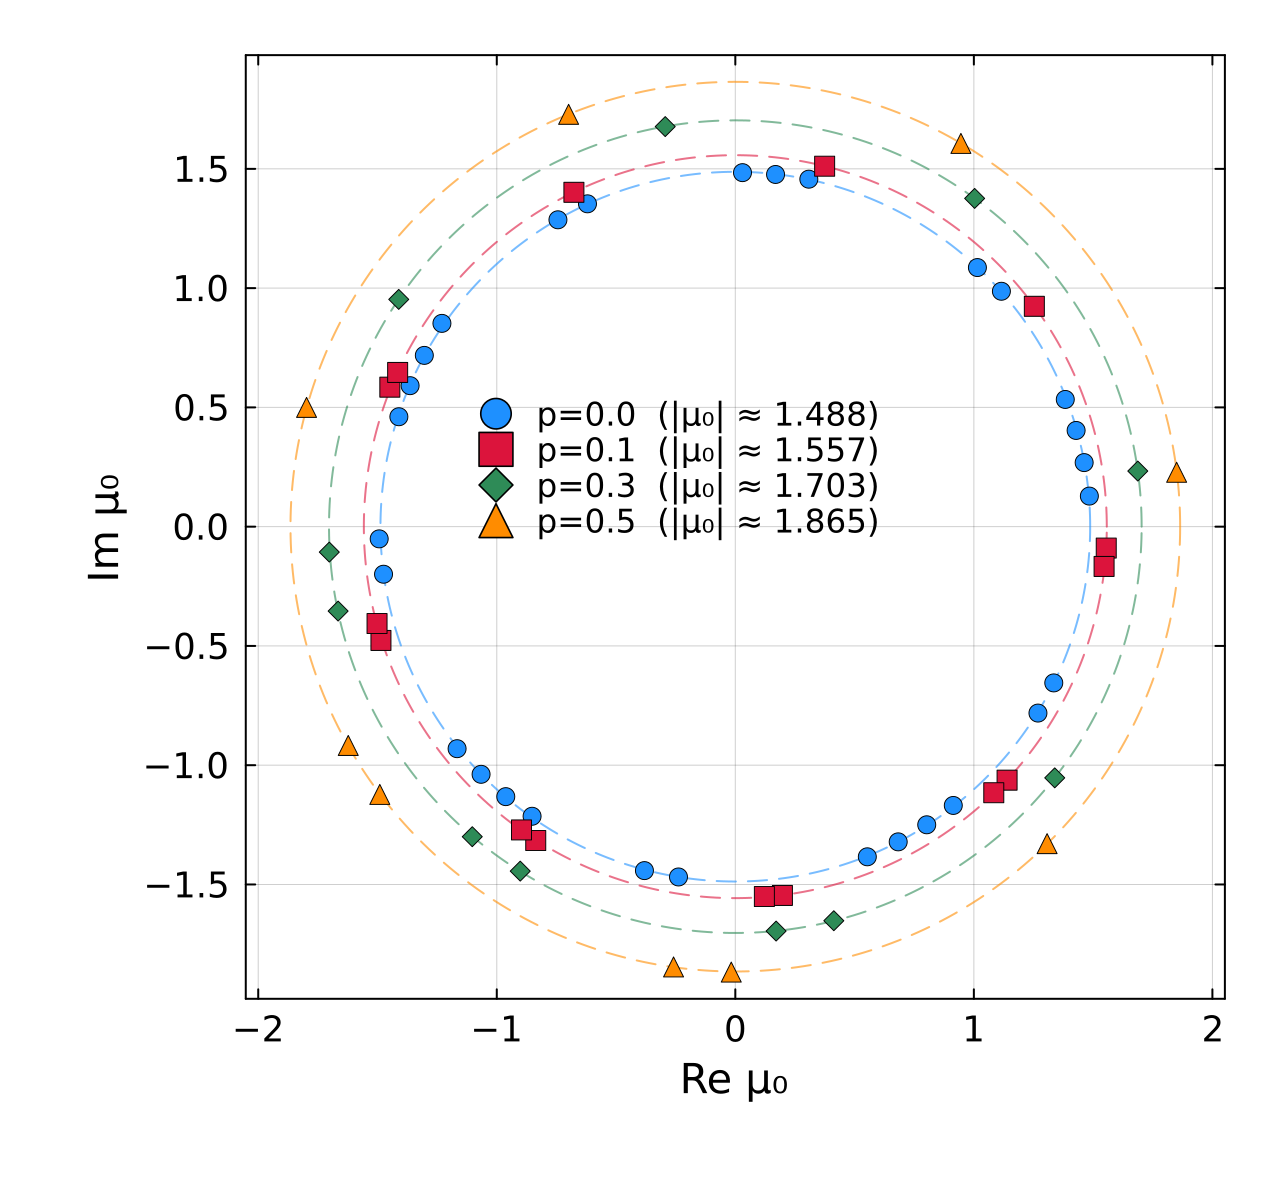

In [3]:
# each coupling on its own circle: mu0 raw, dashed circle at the ladder-mean modulus
arm(file, label) = Dict(k[2] => v for (k, v) in load(joinpath("../data/cluster", file), "done")
                        if k[1] == label && !haskey(v, :error))
spec = Dict(
    0.0 => merge(arm("sweep_rtm_eigs_p0.0.jld2", "rtm_eigs_p0.0"),
                 arm("sweep_rtm_eigs_p0.0_fine.jld2", "rtm_eigs_p0.0_fine")),
    0.1 => merge(arm("sweep_rtm_eigs_p0.1_bulk.jld2", "rtm_eigs_p0.1_bulk"),
                 arm("sweep_rtm_eigs_p0.1_fine_bulk.jld2", "rtm_eigs_p0.1_fine_bulk")),
    0.3 => merge(arm("sweep_ent_p0.3_bulk.jld2", "ent_p0.3_bulk"),
                 arm("sweep_rtm_eigs_p0.3_fine_bulk.jld2", "rtm_eigs_p0.3_fine_bulk")),
    0.5 => merge(arm("sweep_ent_p0.5_bulk.jld2", "ent_p0.5_bulk"),
                 arm("sweep_rtm_eigs_p0.5_fine_bulk.jld2", "rtm_eigs_p0.5_fine_bulk")))

pl = plot(xlabel="Re μ₀", ylabel="Im μ₀", aspect_ratio=:equal, legend=(0.30, 0.62),
          size=(640, 600))
th = range(0, 2pi, length=400)
for p in (0.0, 0.1, 0.3, 0.5)
    z = [spec[p][T].theta_phys for T in sort(collect(keys(spec[p])))]
    r = mean(abs.(z))
    plot!(pl, r .* cos.(th), r .* sin.(th), color=P_COLOR[p], ls=:dash, lw=1, alpha=0.6, label="")
    scatter!(pl, real.(z), imag.(z), color=P_COLOR[p], marker=P_MARKER[p], ms=5, msw=0.4,
             label=@sprintf("p=%.1f  (|μ₀| ≈ %.3f)", p, r))
end
pl

## The results, and the coefficient deficit

The fitted central charges are $c = 0.45,\ 0.47,\ 0.49,\ 0.53$ at $p = 0, 0.1, 0.3, 0.5$.
At $p = 0$, where $c = 1/2$ and $v = 2$ are exact, the fitted $1/T^2$ coefficient runs 5–10%
below the CFT prediction — the same effect as reading $c = 0.45$ instead of $0.50$. Two tests
identify the origin as the truncation of the expansion behind Eq. (3):

1. one more order in $1/T$ raises the coefficient from 90% to 97% of the prediction;
2. the coefficient falls **linearly** with the cooling regulator $\beta_0$, and the
   extrapolation $\beta_0 \to 0$ lands on 1.013 of the CFT value:

intercept at beta0=0: 1.013   slope -0.668


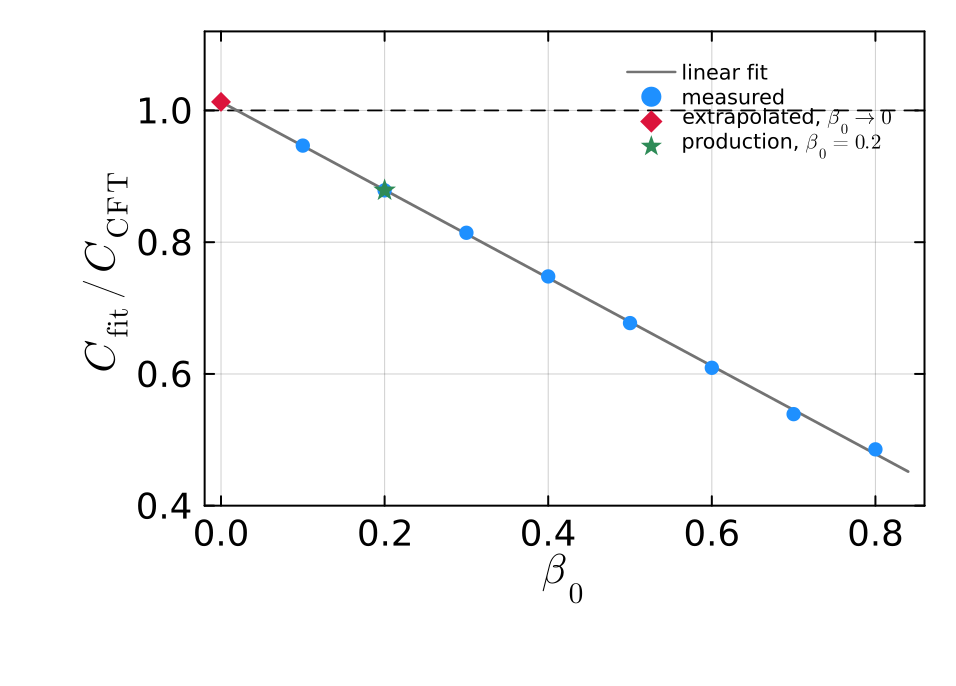

In [4]:
include("../scripts/figures/fig_beta0.jl")
make_beta0()

The production point ($\beta_0 = 0.2$, the green star) sits exactly where the linear
trend says it should. The deficit is systematic and understood — the quoted table keeps the
raw fitted values with the deficit stated alongside.

## Integrable control against non-integrable measurements

The point of the whole exercise, in one table — the $p = 0$ row is exactly solvable, the rest
is genuinely interacting, and every column is measured by the same machinery:

| p | c (equilibrium DMRG) | c (spectral, dynamics) | x₁ measured | x₁ CFT |
|---|---|---|---|---|
| 0.0 | 0.502 | 0.45 | 0.498 | 1/2 |
| 0.1 | 0.502 | 0.47 | 0.497 | 1/2 |
| 0.3 | 0.502 | 0.49 | 0.493 | 1/2 |
| 0.5 | 0.502 | 0.53 | 0.487 | 1/2 |

The spectral route is also robust exactly where the entropy route is fragile: at $p = 0.3$,
$T = 6, 6.5, 7$, six independent cold seeds per rung all converge, phases agreeing to
$\sim 10^{-4}$ (statistics in notebook 6).

## The audit

Every number the thesis quotes, recomputed from the cluster caches alone — central charges,
windows, boundary dimensions, plateau readings:

In [5]:
include("../scripts/analysis/cluster_audit.jl")

=== 1. entropy plateau, and where each ladder stops ===


p=0.0  T=2-18  clean to 15
   

2:0.1334  3:0.1314  4:0.1300  5:0.1287  6:0.1289  7:0.1227  8:0.1243  9:0.1241  10:0.1218  11:0.1249  12:0.1221  13:0.1170  14:0.1218  15:0.1175  16:-1.6831  17:2.8569  18:1.6852
p=0.1  T=2-9  clean to 9
   2:0.1335  2.5:0.1335  3:0.1332  3.5:0.1345  4:0.1344  4.5:0.1338  5:0.1314  5.5:0.1288  6:0.1285  6.5:0.1273  7:0.1307  7.5:0.1289  8:0.1287  8.5:0.1270  9:0.1258
p=0.3  T=2-7  clean to 7
   2:0.1437  2.5:0.1363  3:0.1350  3.5:0.1347  4:0.1323  4.5:0.1315  5:0.1328  5.5:0.1319  6:0.1320  6.5:0.1281  7:0.1260
p=0.5  T=2-6  clean to 6
   2:0.1460  2.5:0.1346  3:0.1341  3.5:0.1373  4:0.1372  4.5:0.1414  5:0.1244  5.5:0.1348  6:0.1398
p=1.0  T=2-3.25  clean to 3.25
   2:0.1366  2.25:0.1341  2.5:0.1325  2.75:0.1333  3:0.1340  3.25:0.1366

=== 2. the Bou-Comas extrapolation of the plateau, cluster ladders ===
p=0.0  14 rungs T=2-15   sqrtT: a=0.1117 -> c=0.569   two-term: a=0.1141 -> c=0.581


p=0.1  15 rungs T=2-9   sqrtT: a=0.1209 -> c=0.616   two-term: a=0.1188 -> c=0.605
p=0.3  11 rungs T=2-7   sqrtT: a=0.1131 -> c=0.576   two-term: a=0.1248 -> c=0.636
p=0.5   9 rungs T=2-6   sqrtT: a=0.1246 -> c=0.634   two-term: a=0.1479 -> c=0.753

=== 3. Eq.(3) on every corrected-column eigenvalue arm ===
p=0.0  29 pts T=2-20  dof=27  |C|=0.02952  c=0.4510  rms=4.1e-05
p=0.1  15 pts T=2-9  dof=13  |C|=0.02284  c=0.4660  rms=2.4e-05


p=0.3  11 pts T=2-7  dof=9  |C|=0.01629  c=0.4937  rms=1.3e-05
p=0.5   9 pts T=2-6  dof=7  |C|=0.01339  c=0.5332  rms=5.8e-05
p=1.0   6 pts T=2-3.25  dof=4  |C|=0.00887  c=0.5509  rms=5.4e-06

=== 4. modulus spread, the dual-unitarity check ===
p=0.0  T=2-20  |μ₀| 1.4825-1.4963  spread 0.93%
p=0.1  T=2-9  |μ₀| 1.5549-1.5619  spread 0.45%
p=0.3  T=2-7  |μ₀| 1.7023-1.7054  spread 0.18%
p=0.5  T=2-6  |μ₀| 1.8638-1.8674  spread 0.19%

=== 5. x1: free boundary at p=0 from the cluster arm, over its full window ===
  T=2-9 (8 pts): fit x1=0.4965   per-time 0.452..0.503  last=0.503


  T=2-14 (13 pts): fit x1=0.4973   per-time 0.452..0.503  last=0.499
  T=2-20 (19 pts): fit x1=0.4977   per-time 0.452..0.506  last=0.500

=== 6. x1 at the last time of each corrected-column tower arm ===
p=0.1  last T=8  x = 0.497, 1.494, 1.993
p=0.3  last T=6  x = 0.493, 1.498, 2.004


p=0.5  last T=4.5  x = 0.487, 1.499, 2.013
p=1.0  last T=3  x = 0.494, 1.568, 2.140
